In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import seaborn as sns

###### Descripción de los datos

En total hay 21 columnas el los datos, las cuáles se describen a continuación:

  - ID: Correlativo númerico que distingue cada una de las casas vendidas.
  - Date: Fecha en la cual fue vendida la casa.
  - Price: Precio de venta de la casa (en dólares norteamericanos).
  - Bedrooms: Número de cuartos en la casa.
  - Bathrooms: Número de baños disponibles en la casa, donde un valor de 0.5 representa un baño con inodoro pero si
  - Sqft_living15: Los pies cuadrados de espacio habitable de la casa interior para los 15 vecinos más cercanos.
  - Sqft_lot15: Los metros cuadrados de los terrenos de los 15 vecinos más cercanos.n ducha.
  - Sqft_living: Número de pies cuadrados del espacio habitable de la casa.
  - Sqft_lot: Pies cuadrados del espacio total del terreno donde se ubica la casa.
  - Floors: Cantidad de pisos en la casa.
  - Waterfront: Variable que indica la presencia o no de vista al mar en la casa.
  - View: Índice del 0 al 4 que indica que tan buena es la vista de la propiedad.
  - Condition: Índice del 1 al 5 para calificar la condición actual de la casa.
  - Grade: Índice del 1 al 13, el cuál califica el nivel de calidad de construcción de la casa.
  - Sqft_above: Cantidad de pies cuadrados del espacio interior de la casa. que está sobre el nivel del suelo.
  - Sqft_basement: Los pies cuadrados del espacio interior de la casa. que está por debajo del nivel del suelo.
  - Yr_built: El año en fue construida la casa.
  - Yr_renovated: Año de la última renovación de la casa.
  - Zipcode: Código postal del areá donde se encuentra la casa.
  - Lat: Latitud de la ubicación de la casa.
  - Long: Longitud de la15 vecinos más cercanos.

In [2]:
data = pd.read_csv("regresion - House Price.csv",delimiter = ";")
data.head()

,id,date,year,price,bedrooms,bathrooms,sqft_living,sqft_lot,sqft_living15,sqft_lot15,...,bsmt,sqft_bsmt,yr_built,age,yr_renovated,renov,age_renov,zipcode,lat,long
0,7129300520,20141013T000000,2014,221900.0,3,1.00,1180,5650,1340,5650,...,0,0,1955,59,0,0,0,98178,47.5112,-122.257
1,6414100192,20141209T000000,2014,538000.0,3,2.25,2570,7242,1690,7639,...,1,400,1951,63,1991,1,23,98125,47.7210,-122.319
2,5631500400,20150225T000000,2015,180000.0,2,1.00,770,10000,2720,8062,...,0,0,1933,82,0,0,0,98028,47.7379,-122.233
3,2487200875,20141209T000000,2014,604000.0,4,3.00,1960,5000,1360,5000,...,1,910,1965,49,0,0,0,98136,47.5208,-122.393
4,1954400510,20150218T000000,2015,510000.0,3,2.00,1680,8080,1800,7503,...,0,0,1987,28,0,0,0,98074,47.6168,-122.045


In [3]:
data.isnull().sum()

id               0
date             0
year             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
sqft_living15    0
sqft_lot15       0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
bsmt             0
sqft_bsmt        0
yr_built         0
age              0
yr_renovated     0
renov            0
age_renov        0
zipcode          0
lat              0
long             0
dtype: int64

In [4]:
data.dtypes

id                 int64
date              object
year               int64
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
sqft_living15      int64
sqft_lot15         int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
bsmt               int64
sqft_bsmt          int64
yr_built           int64
age                int64
yr_renovated       int64
renov              int64
age_renov          int64
zipcode            int64
lat              float64
long             float64
dtype: object

In [5]:
data["date"] = pd.to_datetime(data.date, format = "%Y%m%dT%H%M%S")

In [6]:
data.dtypes

id                        int64
date             datetime64[ns]
year                      int64
price                   float64
bedrooms                  int64
bathrooms               float64
sqft_living               int64
sqft_lot                  int64
sqft_living15             int64
sqft_lot15                int64
floors                  float64
waterfront                int64
view                      int64
condition                 int64
grade                     int64
sqft_above                int64
bsmt                      int64
sqft_bsmt                 int64
yr_built                  int64
age                       int64
yr_renovated              int64
renov                     int64
age_renov                 int64
zipcode                   int64
lat                     float64
long                    float64
dtype: object

<Axes: >

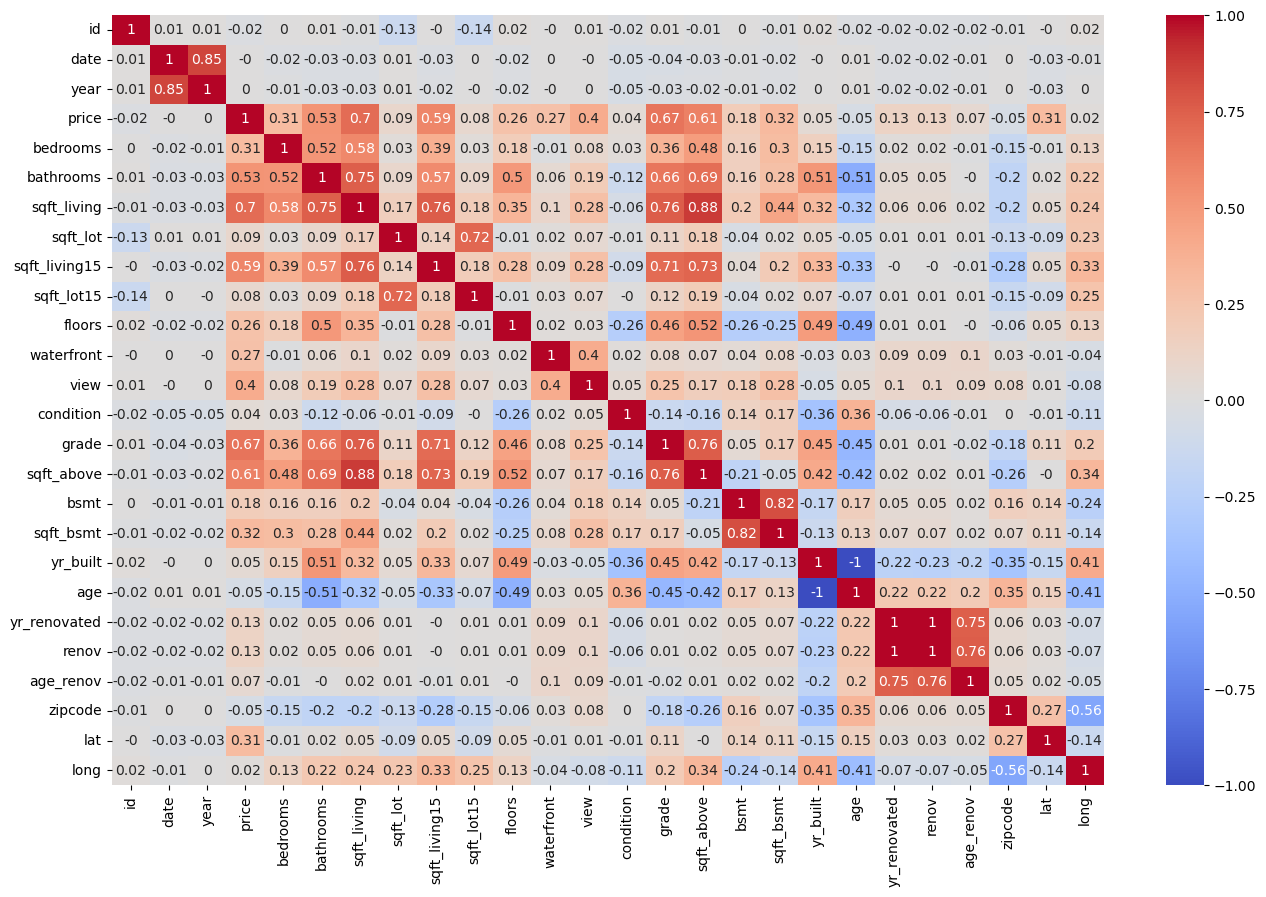

In [7]:
matriz = data.corr().round(2)

plt.figure(figsize = (16,10))
sns.heatmap(matriz, cmap = "coolwarm", annot = True)

In [8]:
data.corr()["price"]

id              -0.016797
date            -0.004366
year             0.003554
price            1.000000
bedrooms         0.308338
bathrooms        0.525134
sqft_living      0.702044
sqft_lot         0.089655
sqft_living15    0.585374
sqft_lot15       0.082456
floors           0.256786
waterfront       0.266331
view             0.397346
condition        0.036392
grade            0.667463
sqft_above       0.605566
bsmt             0.180226
sqft_bsmt        0.323837
yr_built         0.053982
age             -0.053927
yr_renovated     0.126442
renov            0.126101
age_renov        0.067196
zipcode         -0.053168
lat              0.306919
long             0.021571
Name: price, dtype: float64

In [9]:
filtro = data.corr()["price"].abs() > 0.2

In [10]:
relevantes = matriz.loc[filtro, filtro]

<Axes: >

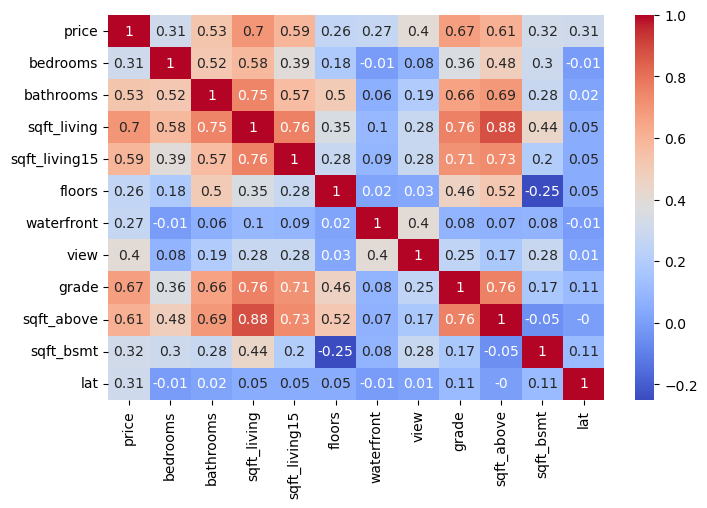

In [11]:
plt.figure(figsize = (8,5))
sns.heatmap(relevantes, cmap = "coolwarm", annot = True)

In [12]:
relevantes["price"].sort_values(ascending = False)

price            1.00
sqft_living      0.70
grade            0.67
sqft_above       0.61
sqft_living15    0.59
bathrooms        0.53
view             0.40
sqft_bsmt        0.32
bedrooms         0.31
lat              0.31
waterfront       0.27
floors           0.26
Name: price, dtype: float64

<Axes: xlabel='sqft_living', ylabel='price'>

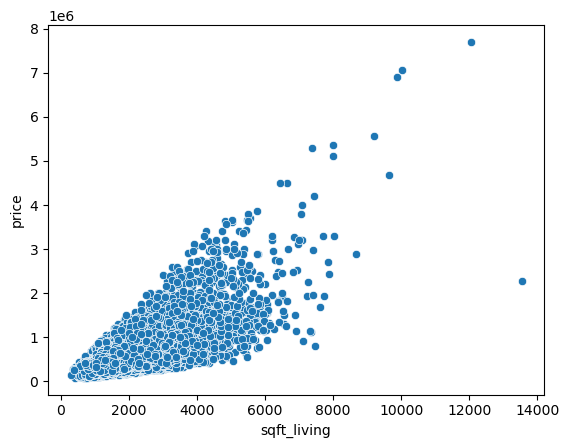

In [13]:
sns.scatterplot(data = data, x = "sqft_living", y = "price")

<Axes: xlabel='grade', ylabel='price'>

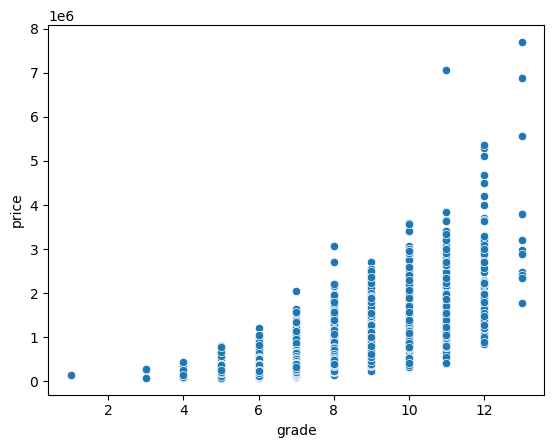

In [14]:
sns.scatterplot(data = data, x = "grade", y = "price")

<Axes: xlabel='sqft_above', ylabel='price'>

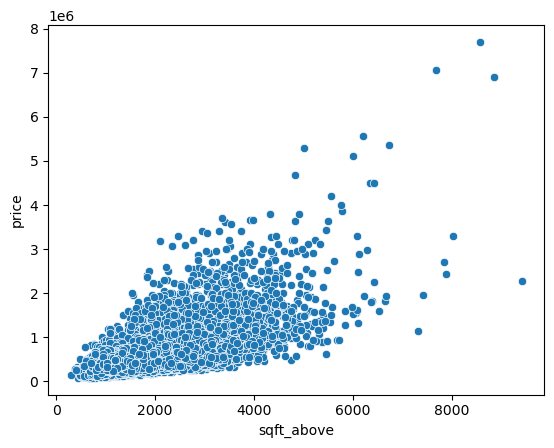

In [15]:
sns.scatterplot(data = data, x = "sqft_above", y = "price")

In [16]:
lm = smf.ols(formula = "price ~ sqft_living", data = data).fit()

In [17]:
lm.rsquared

np.float64(0.49286538652201406)

In [18]:
data["price_pred"] = lm.predict(data.sqft_living)
data.head()

,id,date,year,price,bedrooms,bathrooms,sqft_living,sqft_lot,sqft_living15,sqft_lot15,...,sqft_bsmt,yr_built,age,yr_renovated,renov,age_renov,zipcode,lat,long,price_pred
0,7129300520,2014-10-13,2014,221900.0,3,1.00,1180,5650,1340,5650,...,0,1955,59,0,0,0,98178,47.5112,-122.257,287484.292583
1,6414100192,2014-12-09,2014,538000.0,3,2.25,2570,7242,1690,7639,...,400,1951,63,1991,1,23,98125,47.7210,-122.319,677805.591585
2,5631500400,2015-02-25,2015,180000.0,2,1.00,770,10000,2720,8062,...,0,1933,82,0,0,0,98028,47.7379,-122.233,172353.549712
3,2487200875,2014-12-09,2014,604000.0,4,3.00,1960,5000,1360,5000,...,910,1965,49,0,0,0,98136,47.5208,-122.393,506513.510728
4,1954400510,2015-02-18,2015,510000.0,3,2.00,1680,8080,1800,7503,...,0,1987,28,0,0,0,98074,47.6168,-122.045,427887.637548


<Axes: xlabel='sqft_living', ylabel='price'>

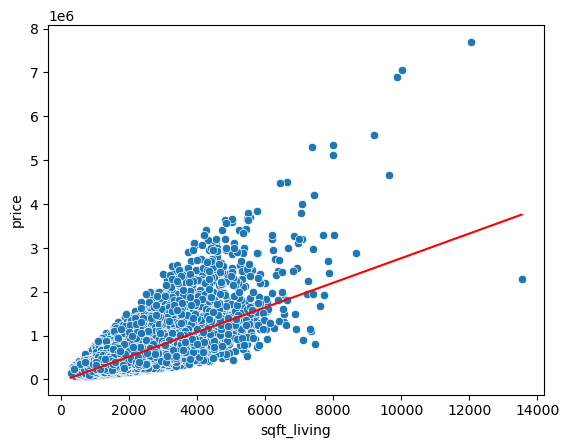

In [21]:
sns.scatterplot(data, x = "sqft_living", y = "price")
sns.lineplot(data, x = "sqft_living", y = "price_pred", color = "red")

In [22]:
lm.params

Intercept     -43867.601534
sqft_living      280.806690
dtype: float64

In [23]:
data["pred_manual"] = -43867.601534 +  280.806690 * data.sqft_living
data.head()

,id,date,year,price,bedrooms,bathrooms,sqft_living,sqft_lot,sqft_living15,sqft_lot15,...,yr_built,age,yr_renovated,renov,age_renov,zipcode,lat,long,price_pred,pred_manual
0,7129300520,2014-10-13,2014,221900.0,3,1.00,1180,5650,1340,5650,...,1955,59,0,0,0,98178,47.5112,-122.257,287484.292583,287484.292666
1,6414100192,2014-12-09,2014,538000.0,3,2.25,2570,7242,1690,7639,...,1951,63,1991,1,23,98125,47.7210,-122.319,677805.591585,677805.591766
2,5631500400,2015-02-25,2015,180000.0,2,1.00,770,10000,2720,8062,...,1933,82,0,0,0,98028,47.7379,-122.233,172353.549712,172353.549766
3,2487200875,2014-12-09,2014,604000.0,4,3.00,1960,5000,1360,5000,...,1965,49,0,0,0,98136,47.5208,-122.393,506513.510728,506513.510866
4,1954400510,2015-02-18,2015,510000.0,3,2.00,1680,8080,1800,7503,...,1987,28,0,0,0,98074,47.6168,-122.045,427887.637548,427887.637666


In [24]:
data["error_cuadratico"] = (data.price - data.pred_manual) **2
error_cuadratico_medio = data.error_cuadratico.mean()

In [25]:
error_promedio = np.sqrt(error_cuadratico_medio)
error_promedio

np.float64(261605.02641474584)

In [26]:
error_promedio / data.price.mean()

np.float64(0.48429038641174293)

In [27]:
relevantes.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_living15',
       'floors', 'waterfront', 'view', 'grade', 'sqft_above', 'sqft_bsmt',
       'lat'],
      dtype='object')

In [28]:
data_relevantes = data.loc[:, relevantes.columns]

In [29]:
data_relevantes.head()

,price,bedrooms,bathrooms,sqft_living,sqft_living15,floors,waterfront,view,grade,sqft_above,sqft_bsmt,lat
0,221900.0,3,1.00,1180,1340,1.0,0,0,7,1180,0,47.5112
1,538000.0,3,2.25,2570,1690,2.0,0,0,7,2170,400,47.7210
2,180000.0,2,1.00,770,2720,1.0,0,0,6,770,0,47.7379
3,604000.0,4,3.00,1960,1360,1.0,0,0,7,1050,910,47.5208
4,510000.0,3,2.00,1680,1800,1.0,0,0,8,1680,0,47.6168


In [31]:
from sklearn.model_selection import train_test_split

In [67]:
X = data_relevantes.drop(columns="price")
y = data_relevantes["price"]

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size = 0.75,
    test_size = 0.25,
    random_state = 10
)

In [69]:
X_train.shape

(16209, 11)

In [70]:
X_test.shape

(5404, 11)

In [71]:
np.linalg.det(X_train.corr())

np.float64(1.180254944071031e-16)

In [72]:
data_train = X_train.copy()
data_train["price"] = y_train

In [37]:
import statsmodels.formula.api as smf

modelo = smf.ols(
    formula = "price ~ bedrooms + bathrooms + sqft_living + sqft_living15 + floors + waterfront + view + grade + sqft_above + sqft_bsmt + lat", 
    data = data_train
).fit()

In [39]:
modelo.pvalues < 0.05

Intercept         True
bedrooms          True
bathrooms        False
sqft_living       True
sqft_living15     True
floors            True
waterfront        True
view              True
grade             True
sqft_above        True
sqft_bsmt         True
lat               True
dtype: bool

In [73]:
from sklearn.linear_model import LinearRegression

In [74]:
dicc = {}
for i in X_train.columns:
    X_vif = X_train.drop(columns=i)
    y_vif = X_train[i]
    
    
    lm = LinearRegression()
    lm.fit(X_vif, y_vif)
    r_2 = lm.score(X_vif, y_vif)

    if r_2 == 1:
        VIF = np.inf
    else: 
        VIF = 1/(1-r_2)
    dicc[i] = round(VIF,2) if np.isfinite(VIF) else np.inf

In [75]:
dicc

{'bedrooms': 1.61,
 'bathrooms': 2.95,
 'sqft_living': inf,
 'sqft_living15': 2.86,
 'floors': 1.84,
 'waterfront': 1.2,
 'view': 1.37,
 'grade': 3.26,
 'sqft_above': inf,
 'sqft_bsmt': inf,
 'lat': 1.05}

In [76]:
X_train_bis = X_train.drop(columns=["sqft_living"])
X_test_bis = X_test.drop(columns=["sqft_living"])

In [77]:
dicc = {}
for i in X_train_bis.columns:
    X_vif = X_train_bis.drop(columns=i)
    y_vif = X_train_bis[i]
    
    
    lm = LinearRegression()
    lm.fit(X_vif, y_vif)
    r_2 = lm.score(X_vif, y_vif)

    if r_2 == 1:
        VIF = np.inf
    else: 
        VIF = 1/(1-r_2)
    dicc[i] = round(VIF,2) if np.isfinite(VIF) else np.inf

In [78]:
dicc

{'bedrooms': 1.61,
 'bathrooms': 2.95,
 'sqft_living15': 2.86,
 'floors': 1.84,
 'waterfront': 1.2,
 'view': 1.37,
 'grade': 3.26,
 'sqft_above': 4.73,
 'sqft_bsmt': 1.93,
 'lat': 1.05}

In [79]:
from sklearn.svm import SVR
from sklearn.feature_selection import RFE

In [80]:
estimador = SVR(kernel= "linear")
selector = RFE(
    estimador,
    n_features_to_select = 9
)
selector = selector.fit(X_train_bis, y_train)

In [82]:
filtro = selector.support_

In [83]:
X_train_final = X_train_bis.loc[:,filtro]
X_test_final = X_test_bis.loc[:,filtro]

In [84]:
lm = LinearRegression()
lm.fit(X_train_final, y_train)
lm.score(X_test_final, y_test)

0.6594146479645133